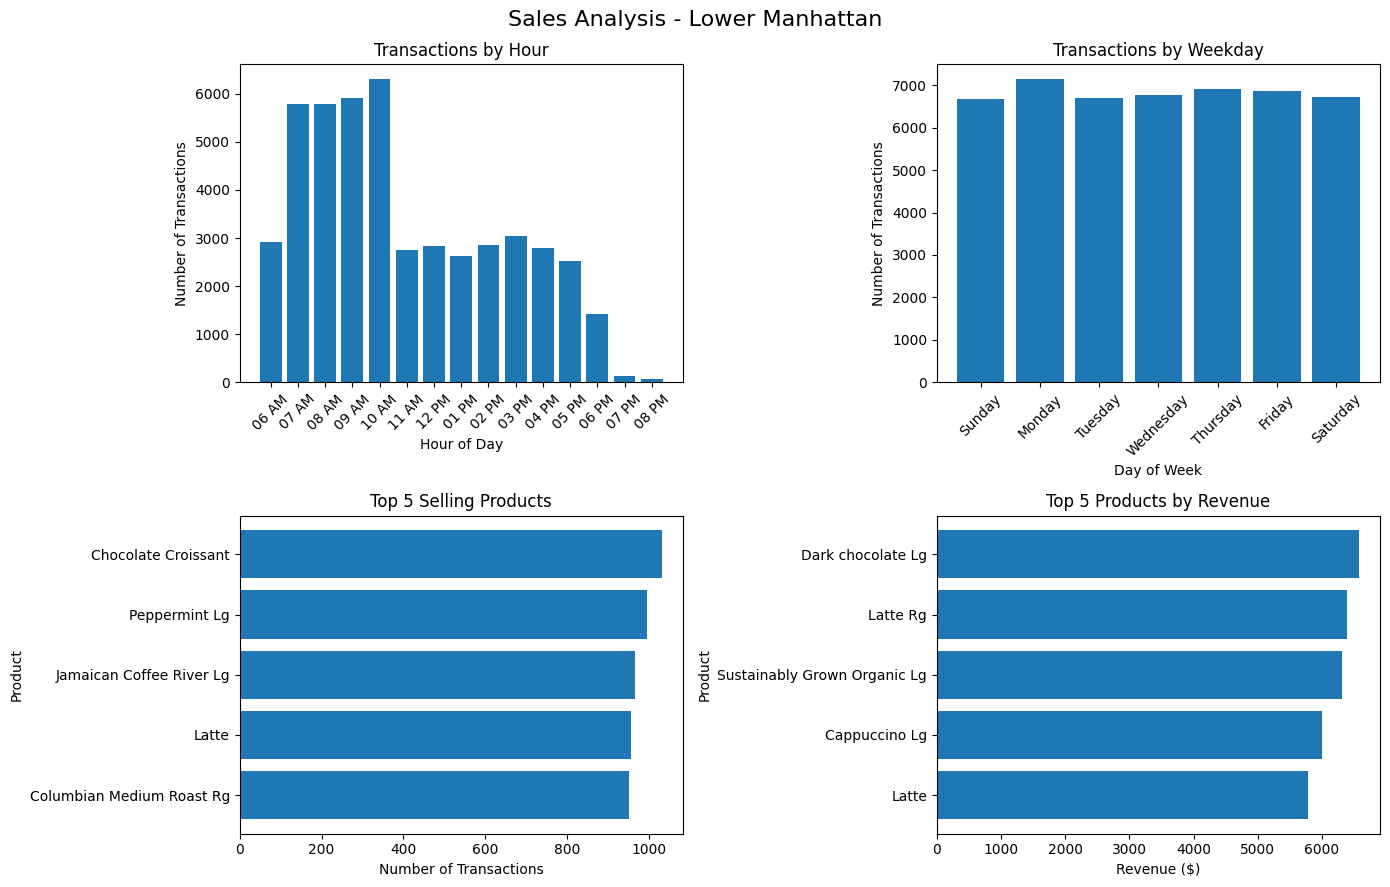

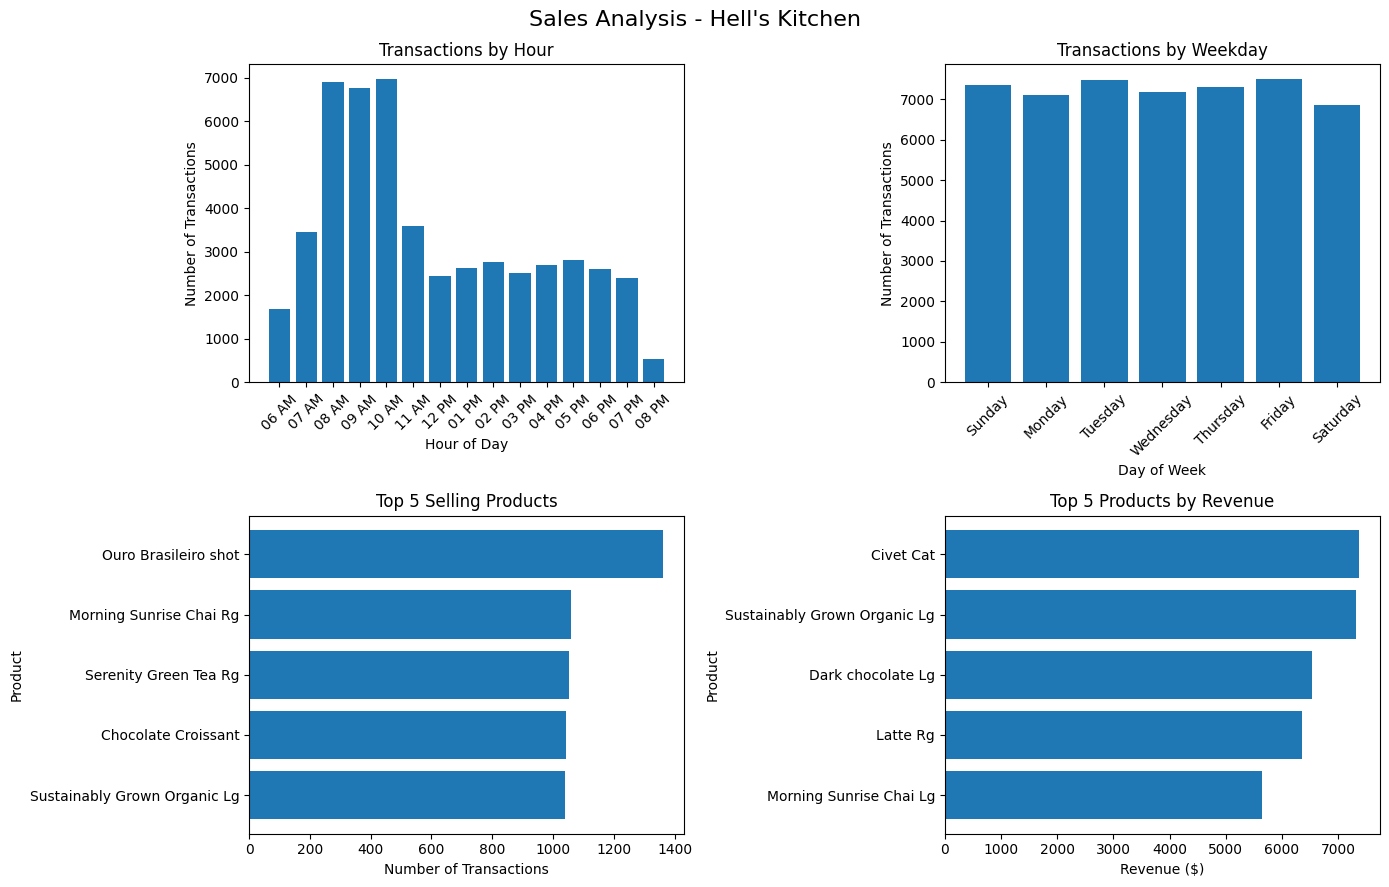

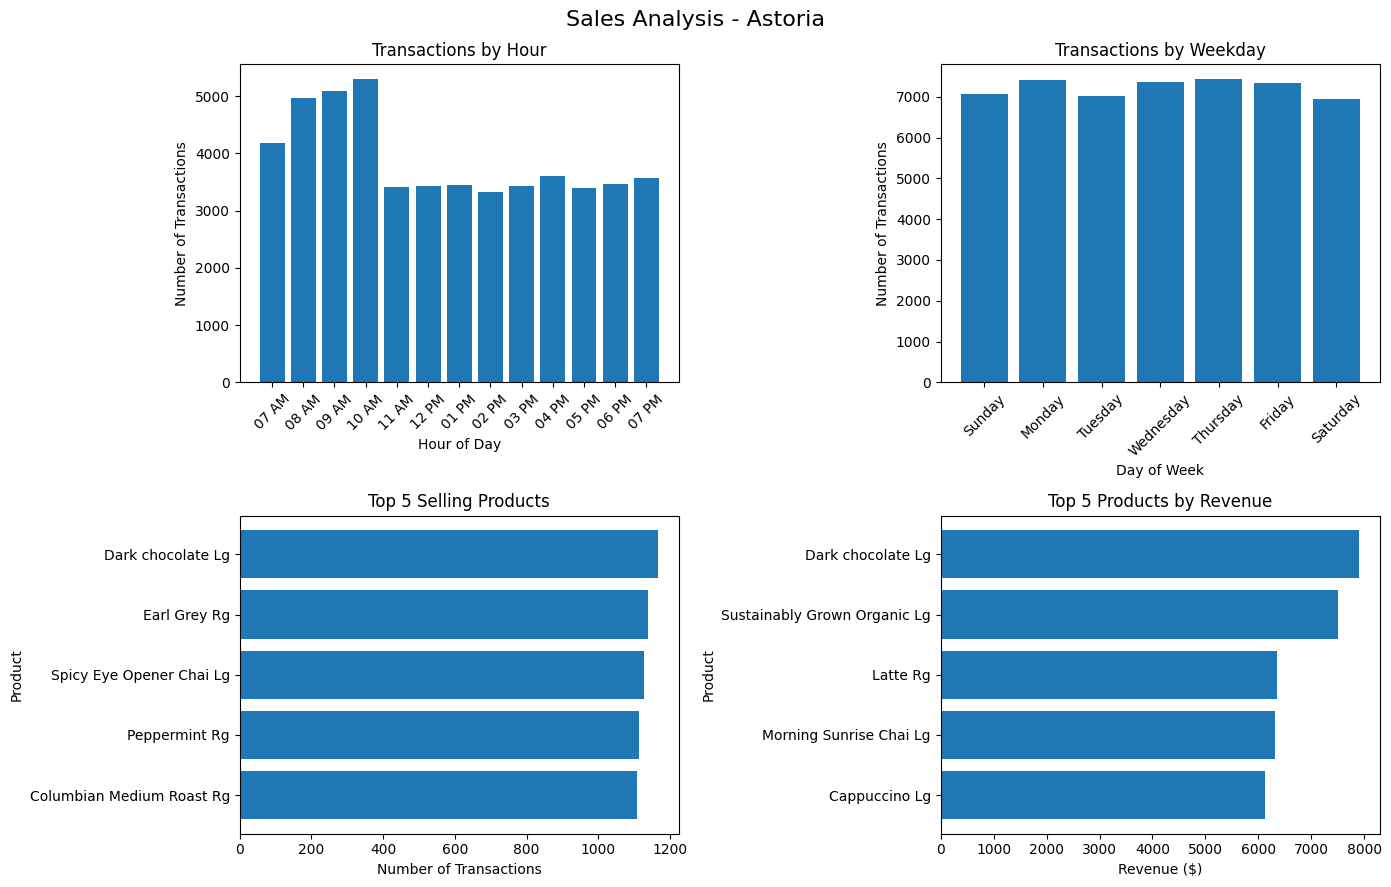

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("../data/Coffee_shop_sales.xlsx")

# Computing revenue (quantity * unit price)
df["revenue"] = df["transaction_qty"] * df["unit_price"]

df["transaction_time"] = pd.to_datetime(
    df["transaction_time"].astype(str),
    format= "%H:%M:%S", 
    errors = "coerce"
)

# Drop any bad rows
df = df.dropna(subset=["transaction_time"])

# Extract hour from transaction_time
df["hour"] = df["transaction_time"].dt.hour
df["hour_label"] = df["transaction_time"].dt.strftime("%I %p")

df["transaction_date"] = pd.to_datetime(df["transaction_date"])
df["weekday"] = df["transaction_date"].dt.day_name()

weekday_order = [
    "Sunday", "Monday", "Tuesday", "Wednesday", 
    "Thursday", "Friday", "Saturday"
    ]

store_locations = df["store_location"].unique()

for store in store_locations:
    store_df = df[df["store_location"] == store].copy()

    fig, axes = plt.subplots(2, 2, figsize=(14,9))
    fig.suptitle(f"Sales Analysis - {store}", fontsize=16)

    # Hourly sales
    store_hourly = store_df.groupby(["hour", "hour_label"])["revenue"].agg(["count", "sum"]).reset_index()
    store_hourly = store_hourly.rename(columns={
        "count": "transactions",
        "sum": "revenue"
    })
    store_hourly = store_hourly.sort_values("hour")

    axes [0,0].bar(store_hourly["hour_label"], store_hourly["transactions"])
    
    axes[0,0].set_title("Transactions by Hour")
    axes[0,0].set_xlabel("Hour of Day")
    axes[0,0].set_ylabel("Number of Transactions")
    axes[0,0].tick_params(axis="x", rotation=45)

    # Weekday sales
    weekday_sales = store_df.groupby("weekday")["revenue"].agg(["count", "sum"]).reset_index()
    weekday_sales = weekday_sales.rename(columns={
        "count": "transactions",
        "sum": "revenue"
    })
    weekday_sales["weekday"] = pd.Categorical(
        weekday_sales["weekday"],
        categories=weekday_order,
        ordered=True
    )
    weekday_sales = weekday_sales.sort_values("weekday")
    axes[0,1].bar(weekday_sales["weekday"], weekday_sales["transactions"])
    axes[0,1].set_title("Transactions by Weekday")
    axes[0,1].set_xlabel("Day of Week")
    axes[0,1].set_ylabel("Number of Transactions")
    axes[0,1].tick_params(axis="x", rotation=45)

    # Top 5 products
    product_sales = store_df.groupby("product_detail")["revenue"].agg(["count", "sum"]).reset_index()
    product_sales = product_sales.rename(columns={
        "count": "transactions",
        "sum": "revenue"
    })
    top5_products = product_sales.sort_values("transactions", ascending=False).head(5)
    axes[1,0].barh(top5_products["product_detail"], top5_products["transactions"])
    axes[1,0].set_title("Top 5 Selling Products")
    axes[1,0].set_xlabel("Number of Transactions")
    axes[1,0].set_ylabel("Product")
    axes[1,0].invert_yaxis()

# Top 5 by revenue
    top5_revenue = product_sales.sort_values("revenue", ascending=False).head(5)

    axes[1,1].barh(top5_revenue["product_detail"], top5_revenue["revenue"])
    axes[1,1].set_title("Top 5 Products by Revenue")
    axes[1, 1].set_xlabel("Revenue ($)")
    axes[1, 1].set_ylabel("Product")
    axes[1, 1].invert_yaxis()

    plt.tight_layout()
    plt.show()



    
